# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [ ]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [ ]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


## **Espacio de Trabajo**

### **Parte 1** — Ajuste del modelo y coeficientes (interpretación)

### **Parte 1.1** — Ajuste del modelo y coeficientes


In [ ]:
X = sm.add_constant(df[['horas','asistencia','promedio']])
m3 = sm.OLS(df['nota'], X).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        14:35:29   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

### **Parte 1.2** — **Interpretación**
- Si `horas` aumenta en **1 unidad**, la nota esperada cambia en **+0.0412** puntos, **manteniendo constantes** los demás **predictores** del modelo.
- Si `asistencia` aumenta en **1 unidad**, la nota esperada cambia en **+0.0106** puntos, **manteniendo constantes** los demás **predictores** del modelo.
- Si `promedio` aumenta en **1 unidad**, la nota esperada cambia en **+0.5753** puntos, **manteniendo constantes** los demás **predictores** del modelo.

### **Parte 1.3** — **Efecto en +5h en** `horas`

In [ ]:
5*0.0412

0.20600000000000002

- **Conclusión**: Si `horas` aumenta en **5 unidades**, la nota esperada cambia en **+0.206** puntos, **manteniendo constantes** los demás **predictores** del modelo.

### **Parte 2** — Significancia (por coeficiente)

### **Parte 2.1** — `horas`

Hipótesis:

*   $H_0: β_j = 0$
*   $H_1: β_j ≠ 0$


$t = 4.610$

$p-valor ≈ 0$

IC95% = [0.024, 0.059]

- Teniendo en cuenta el p-valor y la significancia del 5%, se rechaza $H_0$, por ende se asume que `horas` es diferente de 0, por lo tanto, si afecta en el modelo. Esto se puede evidenciar también en el intervalo de confianza del 95%, donde se evidencia que no hace presencia el 0.

- Sabiendo esto, podemos decir que la variable `horas`, si es significativa, pero cabe aclarar que “significativo” NO es lo mismo que “importante”.

### **Parte 2.2** — `asistencia`

Hipótesis:

*   $H_0: β_j = 0$
*   $H_1: β_j ≠ 0$


$t = 4.817$

$p-valor ≈ 0$

IC95% = [0.006, 0.015]

- Teniendo en cuenta el p-valor y la significancia del 5%, se rechaza $H_0$, por ende se asume que `asistencia` es diferente de 0, por lo tanto, si afecta en el modelo. Esto se puede evidenciar también en el intervalo de confianza del 95%, donde se evidencia que no hace presencia el 0.

- Sabiendo esto, podemos decir que la variable `asistencia`, si es significativa, pero cabe aclarar que “significativo” NO es lo mismo que “importante”.

### **Parte 2.3** — `promedio`

Hipótesis:

*   $H_0: β_j = 0$
*   $H_1: β_j ≠ 0$


$t = 11.422$

$p-valor ≈ 0$

IC95% = [0.476, 0.674]

- Teniendo en cuenta el p-valor y la significancia del 5%, se rechaza $H_0$, por ende se asume que `promedio` es diferente de 0, por lo tanto, si afecta en el modelo. Esto se puede evidenciar también en el intervalo de confianza del 95%, donde se evidencia que no hace presencia el 0.

- Sabiendo esto, podemos decir que la variable `promedio`, si es significativa, pero cabe aclarar que “significativo” NO es lo mismo que “importante”.

### **Parte 3** — Residuales (lectura rápida y profesional)

### **Parte 3.1** — Calculo de residuales

In [ ]:
residuals = m3.resid
fitted_values = m3.fittedvalues

print("Residuals (Primeros 3):")
print(residuals.head(3))
print("\nFitted Values (Primeros 3):")
print(fitted_values.head(3))

Residuals (Primeros 3):
0    0.0073
1    0.3738
2    0.1859
dtype: float64

Fitted Values (Primeros 3):
0    3.1880
1    3.1423
2    3.7254
dtype: float64


### **Parte 3.2** — Gráficas

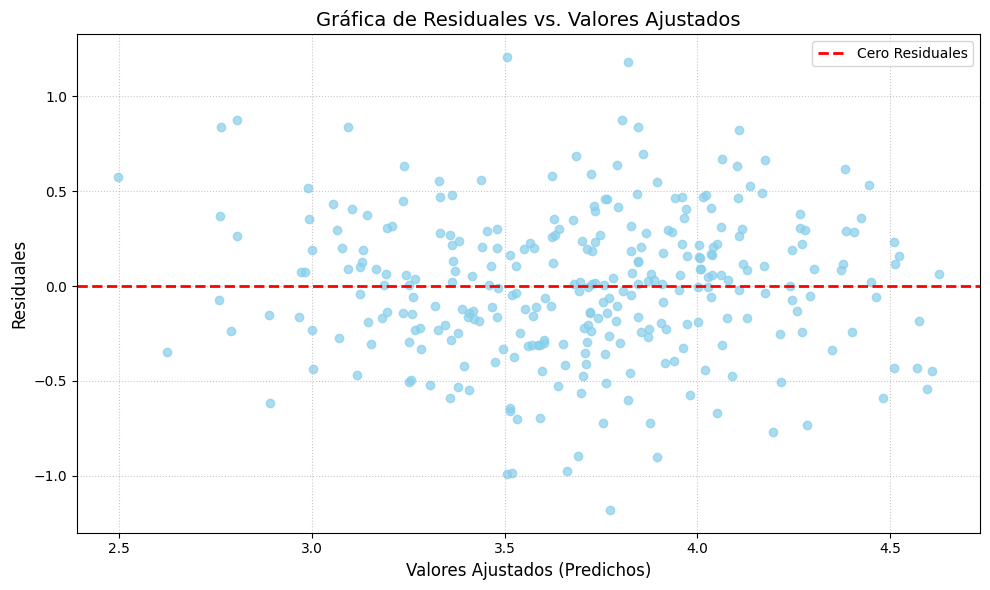

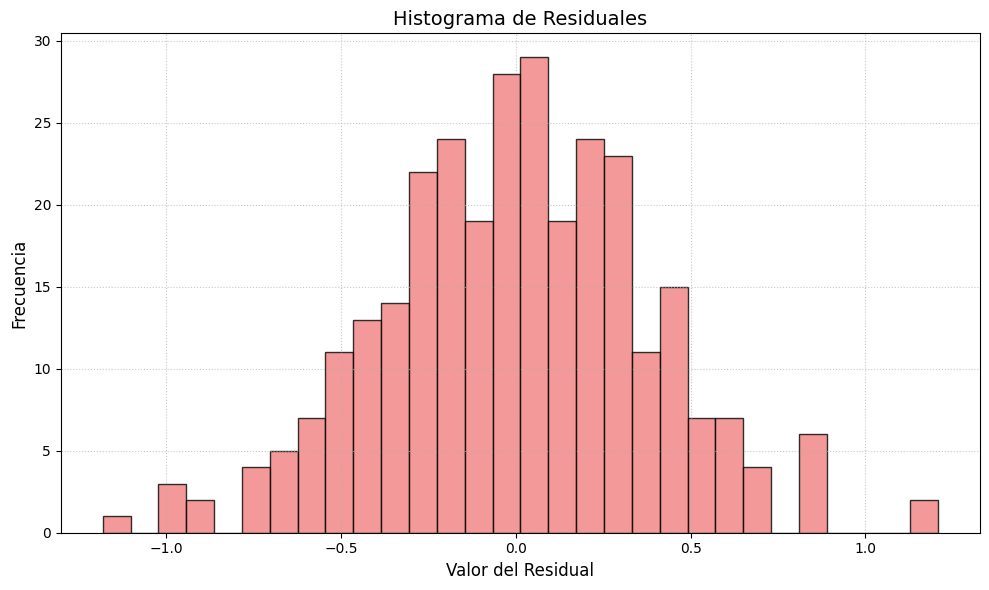

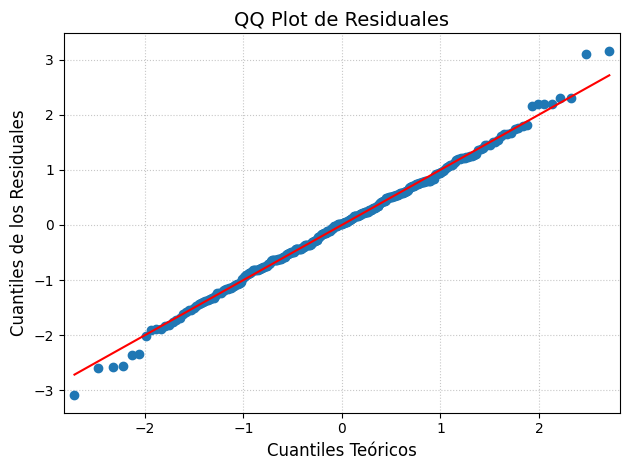

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# G1: Residuales vs Ajustados (scatter) + línea horizontal en 0
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.7, color='skyblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Cero Residuales')
plt.xlabel('Valores Ajustados (Predichos)', fontsize=12)
plt.ylabel('Residuales', fontsize=12)
plt.title('Gráfica de Residuales vs. Valores Ajustados', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Histograma de residuales
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.8, color='lightcoral')
plt.xlabel('Valor del Residual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Histograma de Residuales', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# QQ plot de residuales
sm.qqplot(residuals, line='s', fit=True)
plt.title('QQ Plot de Residuales', fontsize=14)
plt.xlabel('Cuantiles Teóricos', fontsize=12)
plt.ylabel('Cuantiles de los Residuales', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### **Parte 3.3** — Bullets

*   **Patrón:** En la gráfica de Residuales vs. Valores Ajustados (G1), se observa una "nube" de puntos distribuidos aleatoriamente alrededor de la línea horizontal en cero, sin un patrón claro de curva o abanico. Esto indica que existe una relación lineal adecuada y que la varianza de los errores es aproximadamente constante.

*   **Outliers:** No se aprecian outliers extremadamente evidentes, es decir, puntos que se alejen mucho de la nube principal de residuales, lo que sugiere que no hay observaciones inusuales. Hay ciertos puntos que se alejan un poco de la concentración de la nube y de la linea pero no se consideran outliers.

*   **Supuesto de abanico:** Si se observara un patrón de abanico en la gráfica, el supuesto que podría fallar es el de **homocedasticidad**, que establece que la varianza de los errores es constante para todos los niveles de los predictores. En este caso, no se ve ese patrón de abanico, por ende, concluimos de que el supuesto de **homocedasticidad** se cumple.

### **Parte 4** — Modificación obligatoria (para forzar nueva interpretación)

### **Parte 4.1** - ¿Por qué cambia el número? - ¿Cómo cambia la interpretación en palabras?

In [ ]:
df['horas10'] = df['horas'] / 10
X_m3b = sm.add_constant(df[['horas10', 'asistencia', 'promedio']])
m3b = sm.OLS(df['nota'], X_m3b).fit()
print(m3b.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        16:28:13   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

- El número de horas si sufre un cambio ya que está en diferente unidad de medición y ahora el coeficiente es 0.4117, en este momento, si se aumenta una unidad, la nota se verá afectada pero en el modelo, no se cambiará mucho o practicamente nada, el ajuste y las mediciones seguiran siendo las mismas.

### Párrafo Final del Análisis

El modelo indica que las horas de estudio, la asistencia y el promedio previo están relacionadas positivamente con la nota: estudiar más, asistir más a clase y tener un mejor promedio suelen aumentar la calificación esperada. Todas estas variables resultaron ser estadísticamente significativas, lo que sugiere que su efecto no es producto del azar, aunque esto no significa necesariamente que tengan la misma importancia práctica o que exista una causalidad directa. El análisis de los residuales no muestra problemas importantes, por lo que los supuestos del modelo parecen cumplirse razonablemente. Además, cambiar la escala de las horas solo modificó el valor numérico del coeficiente, pero no la interpretación ni la relación entre las variables.